## 학습목표 
- 텍스트 데이터에서 수치화하는 다양한 방법
- 문서, 문장, 단어 유사도에 대해서 확인

### 1.연관성, 유사도 분석
- 단어 또는 문서끼리 관련성이나 유사도를 파악하는 기술

#### 유사도 
- similarity : 데이터 사이에 비슷한 정도를 측정하는 방법
- 텍스트마이닝 에서는 두 단어 사이의 관계, 두 문서 사이의 관계를 측정할 때 사용
- 유사도의 데이터 간 거리가 가까울수록 유사도가 높다고 판단, 대표적으로 2가지 거리 계산법
    1. 맨해튼 거리 (Manhattan Distance) : 좌표사이의 절대값을 모두 더한 거리값
        - 격자 형태의 도로망에서 길을 찾아가는 것과 유사한 방식
    2. 유클리디안 거리 (Euclidean Distance) : 두점 사이의 최단 직선 거리, 피타고라스 정리를 활용하여 계산하는 거리
        - 인공지능에서 가장 흔히 사용되는 방식

##### 거리기반 알고리즘
1. Manhattan Distance

$d(p,q) = \sum_{i=1}^{n}|p_i-q_i|$


2. Euclidean Distance
$\sqrt{(p_1-q_1)^2+(p_2-q_2)^2+(p_3-q_3)^2+...+(p_n-q_n)^2} = \sqrt{\sum_{i=1}^{n}(p_i-q_i)^2}$

In [1]:
# 유클리디언 거리공식 확인하기
import numpy as np
# 함수정의
def euclidean_sim(A,B):
    return np.sqrt(((A-B)**2).sum())

- 숫자는 특정단어가 나온 횟수
```
doc = [사과,포도,배,귤]
```

In [3]:
doc1 = np.array([0,1,1,1])
doc2 = np.array([1,0,1,1])
doc3 = np.array([3,0,3,3])
# 가설 : 문서2와 문서3은 유사할 것이다

In [4]:
print("문서 1과 문서 2의 유사도 : ",euclidean_sim(doc1,doc2))
print("문서 2과 문서 3의 유사도 : ",euclidean_sim(doc2,doc3))
print("문서 3과 문서 1의 유사도 : ",euclidean_sim(doc3,doc1))

문서 1과 문서 2의 유사도 :  1.4142135623730951
문서 2과 문서 3의 유사도 :  3.4641016151377544
문서 3과 문서 1의 유사도 :  4.242640687119285


#### 결과해석
- 유사도는 숫자가 작을수록 높다 (거리가 가깝다는 이야기)
- 문서1과 문서2의 유사도가 높게 나타남
    - 왜? 단어 1,2개만 다르게 계산되었기 때문에
- 실은 ㅁ누서2,3이 유사해 보이지만, 단지 글이 더 길다는 이유만으로 거리가 멀게 출력됨
- 유클리디언 거리는 글의 길이에 민감하게 반응, 단어가 유사하더라도 문서의 길이에 따라 유사도가 달라짐
- 그래서 글의 길이는 부시하고 방향(내용의 결)만 보는 측정방법이 필요해짐!
    - 코사인 유사도!!! (방향기반 알고리즘)

### 방향기반 알고리즘 
- 단순 거리기반의 유클리디언공식의 단점을 보완
- 코사인 유사도 (Cosine Similarity)
    - 두 벡터사이의 각도 (코사인)으로  유사도를 계산
    - -1 ~ 1 사이의 값으로 도출
    - 문장의 길이, 단어 수 등에 덜 민감하여 텍스트 마이닝에서 선호
    - 값보다는 방향이 중요한 추천시스템 등에 활용

- 코사인 유사도 해석 방법 (-1 ~ 1)
    - -1 : 두 벡터가 완전히 반대방향, 정반대 개념 (ex 좋다:나쁘다, 성공:실패)
    - 0 : 두 벡터가 직각, 의미적 관련이 없음 (ex 행복:컴퓨터)
    - 1 : 두 벡터가 완전히 같은 방향, 의미가 유사 (ex 행복:기쁨, 좋다:만족)

$sim(A,B) = cos(\theta)=A B/||A||||B||$

In [5]:
# 코사인 유사도 함수 만들기
from numpy import dot # 내적, 행렬곱 등을 계산하는 함수
from numpy.linalg import norm # 벡터길이 계산함수

def cos_sim(A,B):
    return dot(A,B)/(norm(A)*norm(B))

In [6]:
doc1 = np.array([0,1,1,1])
doc2 = np.array([1,0,1,1])
doc3 = np.array([3,0,3,3])


print("문서 1과 문서 2의 유사도 : ",cos_sim(doc1,doc2))
print("문서 2과 문서 3의 유사도 : ",cos_sim(doc2,doc3))
print("문서 3과 문서 1의 유사도 : ",cos_sim(doc3,doc1))

문서 1과 문서 2의 유사도 :  0.6666666666666667
문서 2과 문서 3의 유사도 :  1.0
문서 3과 문서 1의 유사도 :  0.6666666666666666


- 뉴스기사 유사도, 추천시스템 등과 같이 텍스트마이닝 계열에서는 단순거리계산이 아닌 `코사인유사도 방식`을 활용하여 유사정도 판별!

### 워드 임베딩 (Word Embedding)
- 단어 의미 보존하며 벡터화 (의미를 가진 수치화)하는 방법
- 인공지능이 문서를 학습하여 단어사이와 관계를 비교하는 방법
- 단순 수치화하는 것이 아니라 의미적 관계를 포함하여 학습함
- 단어가 포함하는 정보가 풍부해진다 (단순 빈도기반 보다 단어사이의 관계성을 포함하기 때문)
- 단어 사이의 관계성이 숫자로 표현되지만, 이는 인공지능이 학습하여 출력한 수치로서 어떤의미를 가지는 수치인지는 사람이 파악할 수 없음

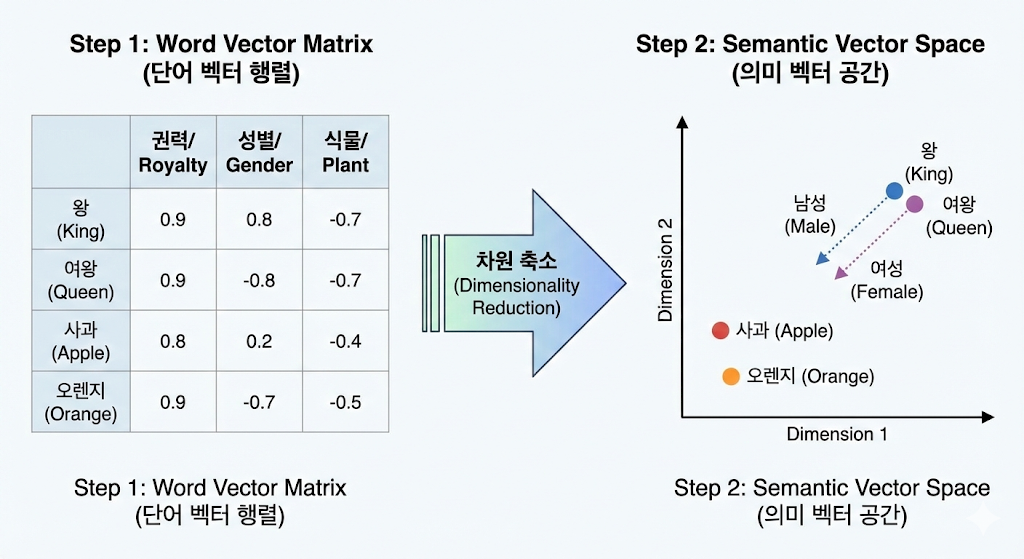

In [7]:
import pandas as pd


In [8]:
data = pd.read_csv("naver_shopping.txt",sep = '\t',header = None)
data.columns = ["평점","리뷰"]

In [9]:
data

,평점,리뷰
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ
...,...,...
199995,2,장마라그런가!!! 달지않아요
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요
199998,5,넘이쁘고 쎄련되보이네요~


In [10]:
from kiwipiepy import Kiwi
kiwi = Kiwi()

In [14]:
data['형태소'] = data['리뷰'].apply(lambda x : [t.form for t in kiwi.tokenize(x) if t.tag in ["VV","VV","NNG"]])

In [15]:
data

,평점,리뷰,형태소
0,5,배공빠르고 굿,"[배, 공, 굿]"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 엉망, 집, 밑, 층, 말, 놔두, 가]"
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[바지, 구매, 가격, 대박, 바느질, 가성비, 최고]"
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 전달, 상품, 머그, 컵, 오, 당황, 전화, 주, 하, 배송, 누락, 확..."
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[민트, 색상, 옆, 손잡이, 용도, 사용]"
...,...,...,...
199995,2,장마라그런가!!! 달지않아요,[장마]
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,"[케이스, 구매, 슈퍼, 드라이기, 케이스, 구매, 가격, 배송, 파, 슈퍼, 드,..."
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,"[사, 배, 이용]"
199998,5,넘이쁘고 쎄련되보이네요~,[쎄련되보]


In [16]:
from gensim.models import Word2Vec

- Word2Vec : 단어를 벡터로 -> 벡터란? 의미를 가지는 수치값

In [17]:
w2v = Word2Vec(
    sentences = [t for t in data['형태소']], # 한줄씩 전달해줘야함
    vector_size = 50, # 임베딩할 벡터의 크기 (한단어가 숫자로 표현되는 크기)
    min_count = 5, # 학습단어로 선정하기 위한 최소등장횟수
    window = 3 # 인접한 단어의 영역을 설정하는 수
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [18]:
len(w2v.wv)

7234

In [19]:
from pyvis.network import Network

In [ ]:
net = Network(notebook = True, cdn_resources = 'in_line')

keyword = "배송"
# 핵심단어의 연관성있는 단어 확보
most_rs = w2v.wv.most_similar(keyword, topn=25) # 연관성 높은 상위 25개의 단어

# 중심노드 추가
net.add_node(keyword)
# 주변노드 추가
for w,s in most_rs : 
    net.add_node(w)
    net.add_edge(w,keyword,v)

### 감성분석 + 단어 유사도 분석

1. 정답데이터 만들기
2. 리뷰데이터 수치화 (TF-IDF)
3. 모델링(모델생성,모델예측,모델평가)

In [20]:
data

,평점,리뷰,형태소
0,5,배공빠르고 굿,"[배, 공, 굿]"
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 엉망, 집, 밑, 층, 말, 놔두, 가]"
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[바지, 구매, 가격, 대박, 바느질, 가성비, 최고]"
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 전달, 상품, 머그, 컵, 오, 당황, 전화, 주, 하, 배송, 누락, 확..."
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[민트, 색상, 옆, 손잡이, 용도, 사용]"
...,...,...,...
199995,2,장마라그런가!!! 달지않아요,[장마]
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,"[케이스, 구매, 슈퍼, 드라이기, 케이스, 구매, 가격, 배송, 파, 슈퍼, 드,..."
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,"[사, 배, 이용]"
199998,5,넘이쁘고 쎄련되보이네요~,[쎄련되보]


In [21]:
# 정답데이터 만들기
data['label'] = data['평점'].apply(lambda x : 1 if x>3 else 0)

In [22]:
data

,평점,리뷰,형태소,label
0,5,배공빠르고 굿,"[배, 공, 굿]",1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 엉망, 집, 밑, 층, 말, 놔두, 가]",0
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[바지, 구매, 가격, 대박, 바느질, 가성비, 최고]",1
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 전달, 상품, 머그, 컵, 오, 당황, 전화, 주, 하, 배송, 누락, 확...",0
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[민트, 색상, 옆, 손잡이, 용도, 사용]",1
...,...,...,...,...
199995,2,장마라그런가!!! 달지않아요,[장마],0
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,"[케이스, 구매, 슈퍼, 드라이기, 케이스, 구매, 가격, 배송, 파, 슈퍼, 드,...",1
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,"[사, 배, 이용]",1
199998,5,넘이쁘고 쎄련되보이네요~,[쎄련되보],1


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [24]:
tfidf = TfidfVectorizer()

In [25]:
# 형태소 문장형태로 변환
data['형태소 문장'] = data['형태소'].apply(lambda x : " ".join(x))

In [26]:
data

,평점,리뷰,형태소,label,형태소 문장
0,5,배공빠르고 굿,"[배, 공, 굿]",1,배 공 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,"[택배, 엉망, 집, 밑, 층, 말, 놔두, 가]",0,택배 엉망 집 밑 층 말 놔두 가
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,"[바지, 구매, 가격, 대박, 바느질, 가성비, 최고]",1,바지 구매 가격 대박 바느질 가성비 최고
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,"[선물, 전달, 상품, 머그, 컵, 오, 당황, 전화, 주, 하, 배송, 누락, 확...",0,선물 전달 상품 머그 컵 오 당황 전화 주 하 배송 누락 확인 하 선물 큰일 나 배...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,"[민트, 색상, 옆, 손잡이, 용도, 사용]",1,민트 색상 옆 손잡이 용도 사용
...,...,...,...,...,...
199995,2,장마라그런가!!! 달지않아요,[장마],0,장마
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...,"[케이스, 구매, 슈퍼, 드라이기, 케이스, 구매, 가격, 배송, 파, 슈퍼, 드,...",1,케이스 구매 슈퍼 드라이기 케이스 구매 가격 배송 파 슈퍼 드 라 익 케이스
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요,"[사, 배, 이용]",1,사 배 이용
199998,5,넘이쁘고 쎄련되보이네요~,[쎄련되보],1,쎄련되보


- tfidf를 통해 단어사전 생성

In [28]:
tfidf.fit(data['형태소 문장'])

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [29]:
len(tfidf.vocabulary_)

19980

In [ ]:
# 구축한 단어사전 기반 tfidf 계산을 통한 변환
review_result = tfidf.transform(data['형태소 문장'])

In [31]:
X = review_result
y = data['label']

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42, stratify = y)

In [34]:
print(X_train.shape,y_train.shape)

(140000, 19980) (140000,)


In [35]:
print(X_test.shape,y_test.shape)

(60000, 19980) (60000,)


In [36]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [37]:
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
model.score(X_test,y_test)

0.76625

#### 워드임베딩 결과로 모델링
- 머신러닝 학습을 위하여 단어벡터의 평균을 구하여 문장벡터로 변환
- 각 단어마다 50차원의 벡터로 변환되었기 때문에 머신러닝 학습은 문장벡터가 필요
- 3개의 단어의 50차원 3개를 평균내서 하나의 50차원으로 변경

In [39]:
import numpy as np

def document_vector(doc,model):
    # 1. 사전에 존재하는 단어만 필터링
    words = [word for word in doc if word in model.wv]

    # 2. 유효 단어가 하나도 없을 경우 -> 0벡터로 변환
    if len(words) == 0:
        return np.zeros(model.vector_size)
    
    # 3. 평균벡터 반환
    return np.mean(model.wv[words],axis = 0)

In [40]:
X = np.array([document_vector(doc,w2v) for doc in data['형태소']])

In [41]:
X.shape

(200000, 50)

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3,random_state = 42, stratify = y)

In [43]:
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression()

In [44]:
model2.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [45]:
model2.score(X_test,y_test)

0.7532833333333333